## Unsupervised Learning
#### by **Marcos Sánchez**
<p><img src="https://cdn.gritglobal.io/uploads/too-broad-customer-segmentation.jpg" width="1000"/></p>

## Segmentacion de Clientes
<p>En esté proyecto nos vamos a enfocar en entender y trabajar un caso de uso para segmentación de clientes, pero antes de eso aquí una pequeña lista de más aplicaciones que se pueden trabajar con los datos recopliados de mis clientes

- Estadística Descriptiva
- Segmentación de Clientes
- Predicción de Abandono
- Valor del Cliente a traves del tiempo (CTLV)

La segmentación la vamos a hacer con base en una metodolgía llamada <b>RFM</b>

</p>

In [1]:
# Importa Pandas, Numpy, Seaborn y Matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Importa el archivo "Online Retail.csv"
df = pd.read_csv("M30 Online Retail.csv", encoding="latin1")


In [2]:
# Análisis Exploratorio
print(df.info())

print("--------------------------------------------------------")
print(df.head(10))

print("--------------------------------------------------------")
print(df["REGION"].unique())
## ¿Cómo se calcula? RFM
##Recency: Se calcula como la diferencia entre la fecha de referencia (por ejemplo, la fecha más reciente del dataset) y la última compra del cliente.
##Frequency: Se cuenta el número de transacciones únicas por cliente.
## Monetary: Se suma el valor total gastado por cliente.





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   INVOICE_NO    541909 non-null  object 
 1   STOCK_CODE    541909 non-null  object 
 2   DESCRIPTION   540455 non-null  object 
 3   QUANTITY      541909 non-null  int64  
 4   INVOICE_DATE  541909 non-null  object 
 5   UNIT_PRICE    541909 non-null  float64
 6   CUSTOMER_ID   406829 non-null  float64
 7   REGION        541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None
--------------------------------------------------------
  INVOICE_NO STOCK_CODE                          DESCRIPTION  QUANTITY  \
0     536365     85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1     536365      71053                  WHITE METAL LANTERN         6   
2     536365     84406B       CREAM CUPID HEARTS COAT HANGER         8   
3     536365     84029G  KNIT

## Recency
<p>Indicador que nos dice que tan reciente es la compra de un cliente</p>

In [14]:
# Obtener los clientes unicos
customer = pd.DataFrame(df["CUSTOMER_ID"].unique(), columns=["CUSTOMER_ID"])
# Tuve que rectificar pq mi anterior código me devolvía un array
# Cuando yo necesitaba un dataFrame

In [18]:
# Obtener la última fecha de compra por cliente
df["INVOICE_DATE"] = pd.to_datetime(df["INVOICE_DATE"], dayfirst=True)
max_purchase = df.groupby("CUSTOMER_ID")["INVOICE_DATE"].max().reset_index(name= "Last_purchase")


In [20]:
max_purchase

,CUSTOMER_ID,Last_purchase
0,12346.0,2020-01-18 10:17:00
1,12347.0,2020-12-07 15:52:00
2,12348.0,2020-09-25 13:13:00
3,12349.0,2020-11-21 09:51:00
4,12350.0,2020-02-02 16:01:00
...,...,...
4367,18280.0,2020-03-07 09:52:00
4368,18281.0,2020-06-12 10:53:00
4369,18282.0,2020-12-02 11:43:00
4370,18283.0,2020-12-06 12:02:00


In [24]:
# Vamos a calcular nuestra metrica de Recency, esto lo haremos restando los días de la última fecha de compra a cada observacón
max_purchase['RECENCY'] = ((df["INVOICE_DATE"].max() + pd.Timedelta(days=1)) - max_purchase["Last_purchase"]).dt.days
                                            #La parte del + pd.Time es para sumar 1 dia 

In [26]:
# Unir el DataFrame de clientes únicos con el que acabamos de crear de la última fecha de compra
customer = pd.merge(customer, max_purchase, on = "CUSTOMER_ID")

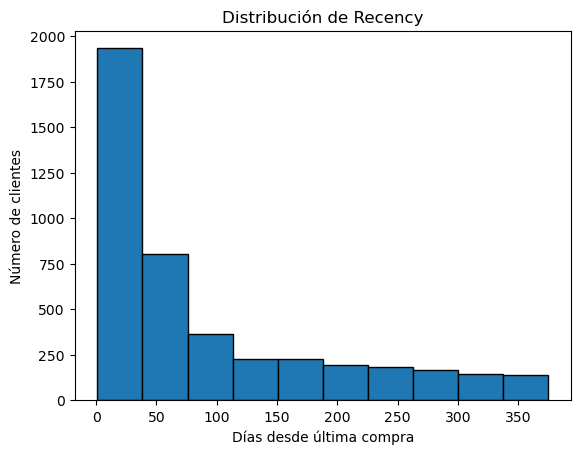

In [28]:
# Grafica un histograma de Recency
plt.hist(customer["RECENCY"], bins=10, edgecolor="black")
plt.title("Distribución de Recency")
plt.xlabel("Días desde última compra")
plt.ylabel("Número de clientes")
plt.show()

In [30]:
# Podemos observar como la mayorí de clientes compran al menos cada 50 días aproximadamente

In [32]:
# Imprime la Estadística de Resumen para Recency
customer["RECENCY"].describe()

count    4372.000000
mean       92.123056
std       100.946554
min         1.000000
25%        17.000000
50%        50.000000
75%       143.000000
max       375.000000
Name: RECENCY, dtype: float64

## Frequency
<p>Frecuencia con la que un cliente compra uno o más productos</p>

In [35]:
# Obtener el número de compras por cliente
frequency  = df.groupby("CUSTOMER_ID")["INVOICE_NO"].nunique().reset_index(name="FREQUENCY")


In [37]:
# Unir el DataFrame que acabamos de crear con el de los clientes unicos
customer  = pd.merge(customer, frequency, on = "CUSTOMER_ID")
customer

,CUSTOMER_ID,Last_purchase,RECENCY,FREQUENCY
0,17850.0,2020-02-10 14:38:00,303,35
1,13047.0,2020-11-08 12:10:00,32,18
2,12583.0,2020-12-07 08:07:00,3,18
3,13748.0,2020-09-05 09:45:00,96,5
4,15100.0,2020-01-13 17:09:00,331,6
...,...,...,...,...
4367,13436.0,2020-12-08 10:33:00,2,1
4368,15520.0,2020-12-08 10:58:00,2,1
4369,13298.0,2020-12-08 13:11:00,1,1
4370,14569.0,2020-12-08 14:58:00,1,1


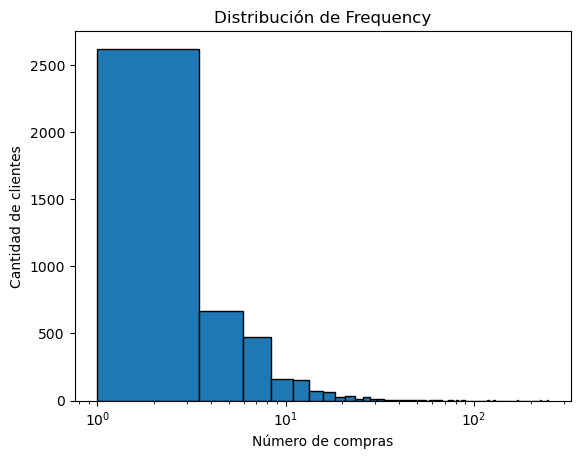

In [41]:
# Grafica un histograma de Frequency
plt.hist(customer["FREQUENCY"], bins=100, edgecolor="black")
plt.title("Distribución de Frequency")
plt.xlabel("Número de compras")
plt.ylabel("Cantidad de clientes")
plt.xscale("log")
## Cambie la escala de x para poder visualizar un poco mejor los datos
plt.show()

In [43]:
# Imprime la Estadística de Resumen para Frequency
customer["FREQUENCY"].describe()

count    4372.000000
mean        5.075480
std         9.338754
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       248.000000
Name: FREQUENCY, dtype: float64

## Monetary
<p>Valor del monto total que ha gastado un cliente en la compra de mis productos</p>

In [46]:
# Calcular el monto total por cada compra
df['MONETARY'] = df["QUANTITY"] * df["UNIT_PRICE"]

# Obtener el valor monetario de compra por cliente
monetary = df.groupby("CUSTOMER_ID")["MONETARY"].sum().reset_index(name="MONETARY")

In [48]:
monetary

,CUSTOMER_ID,MONETARY
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4367,18280.0,180.60
4368,18281.0,80.82
4369,18282.0,176.60
4370,18283.0,2094.88


In [50]:
# Unir el DataFrame que acabamos de crear con el de los clientes unicos
customer  = pd.merge(customer, monetary, on = "CUSTOMER_ID")


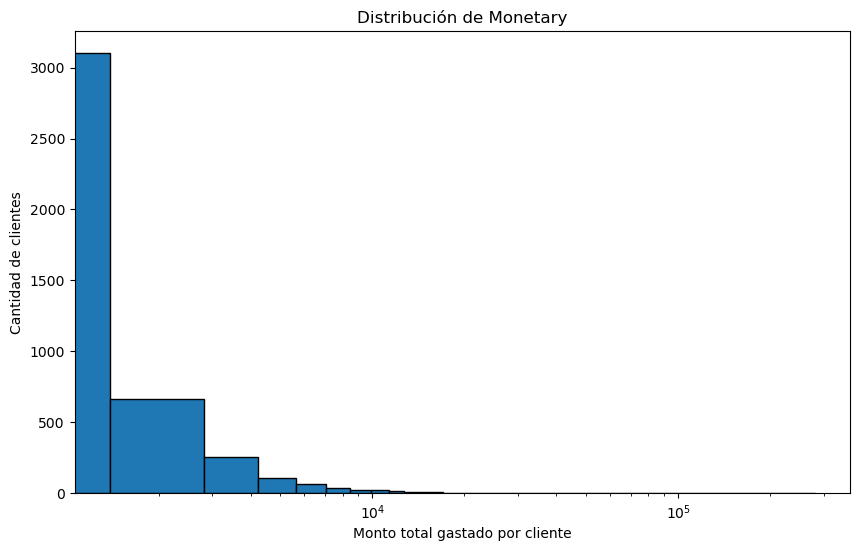

In [52]:
# Grafica un histograma de Monetary
plt.figure(figsize=(10, 6))
plt.hist(customer["MONETARY"], bins=200, edgecolor="black")
plt.title("Distribución de Monetary")
plt.xlabel("Monto total gastado por cliente")
plt.ylabel("Cantidad de clientes")
# Cambie la escala de x para que se pudiera distinguir mejor el cambio respecto a el gasto
plt.xscale("log")
plt.show()

In [54]:
# Imprime la Estadística de Resumen para Monetary
customer["MONETARY"].describe()

count      4372.000000
mean       1898.459701
std        8219.345141
min       -4287.630000
25%         293.362500
50%         648.075000
75%        1611.725000
max      279489.020000
Name: MONETARY, dtype: float64

## Algoritmo k-Means
<p>Ya creamos nuestros indicadores principales de la metodología RFM. es hora de hacer <i>Machine Learning</i>. Para ello utilizaremos un algoritmo no supervisado llamado <b>k-Means</b></p>
<p><img src="https://miro.medium.com/max/818/1*fG8u8nV7qR91wDyFDEEV-g.png" width="250"/></p>

In [57]:
# Funcion para ordenar los clusters
def order_cluster(cluster_field_name, target_field_name, df, ascending):
    new_cluster_field_name = 'new_' + cluster_field_name
    df_new = df.groupby(cluster_field_name)[target_field_name].mean().reset_index()
    df_new = df_new.sort_values(by=target_field_name,ascending=ascending).reset_index(drop=True)
    df_new['index'] = df_new.index
    df_final = pd.merge(df,df_new[[cluster_field_name,'index']], on=cluster_field_name)
    df_final = df_final.drop([cluster_field_name],axis=1)
    df_final = df_final.rename(columns={"index":cluster_field_name})
    return df_final

## Elbow Method
<p>¿Cual es mi número óptimo de clusters? Vamos a contruir una <i>gráfica de codo</i> para averiguarlo</p>

In [60]:
# Importa la librería de kMeans
from sklearn.cluster import KMeans

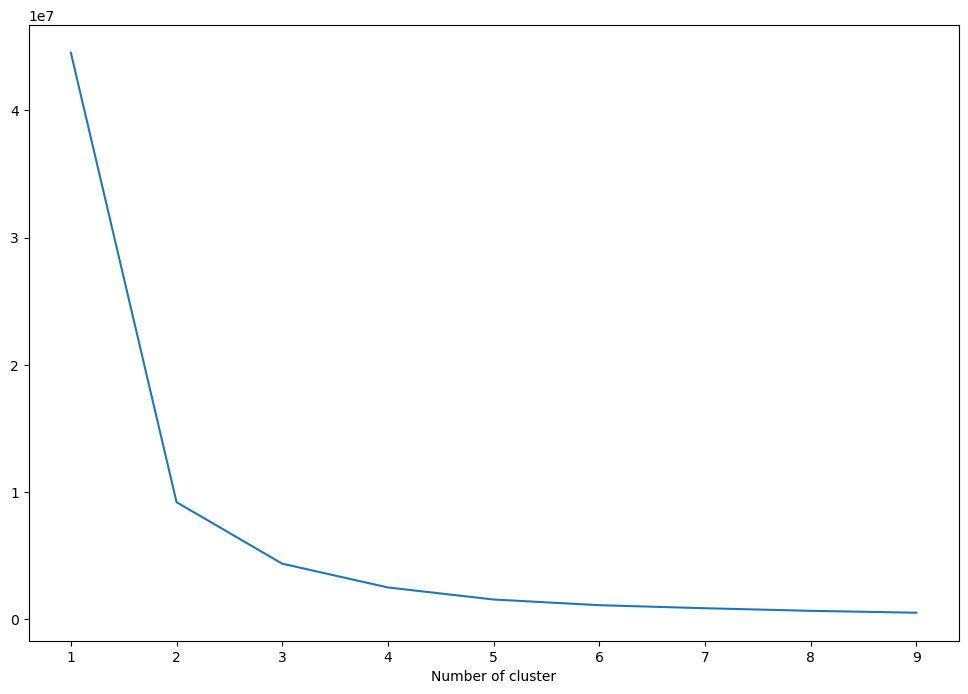

In [66]:
# Configuración inicial - Vamos a tomar como referencia el indicador de Recency
sse={}
recency = pd.DataFrame(customer["RECENCY"])

for k in range(1, 10):
    # Instancia el algoritmo de k-means iterando sobre k
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=2)
    
    # Entrena el algoritmo
    kmeans.fit(recency)
    
    # Adjunta las etiquetas
    recency["clusters"] = kmeans.labels_
    
    # Adunta la inercia o variación al arreglo sse
    sse[k] = kmeans.inertia_
    
# Grafico de codo (Elbow)
plt.figure(figsize=(12,8))
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of cluster")
plt.show()

In [4]:
# Usaremos 4 clusters para Recency debido a que apartir de ahí la reducción de inercia es muy poca

In [ ]:
# Instanciar el algoritmo con 4 clusters para Recency 
kmeans = KMeans(n_clusters=4, init="k-means++", random_state=2)

# Entrenar el algoritmo
kmeans.fit(recency)

# Obtener las predicciones
customer['RECENCY_CLUSTER'] = kmeans.labels_

# Ordenar los clusters
customer = order_cluster('RECENCY_CLUSTER', 'RECENCY', customer, False)

# Estadística Descriptiva del cluster creado
customer.groupby("RECENCY_CLUSTER")["RECENCY"].describe()

,count,mean,std,min,25%,50%,75%,max
RECENCY_CLUSTER,,,,,,,,
0,505.0,310.625743,39.469102,252.0,275.0,307.0,353.0,375.0
1,611.0,192.032733,32.225266,139.0,165.0,190.0,218.0,251.0
2,984.0,84.391260,23.837368,53.0,64.0,78.0,102.0,138.0
3,2272.0,20.036532,14.683479,1.0,8.0,18.0,31.0,52.0


In [ ]:
# Instanciar el algoritmo con 4 clusters para Frequency 
kmeans = KMeans(n_clusters=4, init="k-means++", random_state=2)

# Entrenar el algoritmo
kmeans.fit(customer[["FREQUENCY"]])


# Obtener las predicciones
### Aunque no es una predicción en el sentido supervisado (como regresión o clasificación),
### K-Means asigna una etiqueta a cada punto según su posición relativa.
customer['FREQUENCY_CLUSTER'] = kmeans.labels_

# Ordenar los clusters
customer = order_cluster('FREQUENCY_CLUSTER', 'FREQUENCY', customer, True)

# Estadística Descriptiva de los clusters
customer.groupby("RECENCY_CLUSTER")["FREQUENCY"].describe()

,count,mean,std,min,25%,50%,75%,max
RECENCY_CLUSTER,,,,,,,,
0,505.0,1.536634,1.911521,1.0,1.0,1.0,2.0,35.0
1,611.0,2.224223,1.765926,1.0,1.0,2.0,3.0,14.0
2,984.0,3.036585,2.581861,1.0,1.0,2.0,4.0,20.0
3,2272.0,7.511884,12.272405,1.0,2.0,4.0,8.0,248.0


In [135]:
# Instanciar el algoritmo con 4 clusters para Monetary 
kmeans = KMeans(n_clusters=4, init="k-means++", random_state=2)

# Entrenar el algoritmo
kmeans.fit(customer[["MONETARY"]])


# Obtener las predicciones
customer['MONETARY_CLUSTER'] = kmeans.labels_

# Ordenar los clusters ¿Como tienes que ordenar el cluster?
customer = order_cluster('FREQUENCY_CLUSTER', 'MONETARY', customer, True)

# Estadística Descriptiva de los clusters
customer.groupby("RECENCY_CLUSTER")["MONETARY"].describe()

,count,mean,std,min,25%,50%,75%,max
RECENCY_CLUSTER,,,,,,,,
0,505.0,360.230515,591.834906,-1192.20,136.7700,243.280,393.4900,7741.47
1,611.0,582.773406,1158.810260,-4287.63,184.0200,338.950,631.3700,21535.90
2,984.0,961.785165,1154.098646,-2.95,304.4025,600.975,1181.4875,11581.80
3,2272.0,2999.858385,11244.010090,-1165.30,487.1925,1119.710,2571.2000,279489.02


## Score de Segmentación
<p>El algoritmo de k-means nos da una segmentación generalizada, pero podemos personalizarla aún más creando una métrica que asigne una calificación al valor del cluster. Esto es lo que vamos a hacer!!</p>

In [89]:
# Vamos a crear nuestro score sumando el valor de cada uno de los clusters
customer['SCORE'] = customer['MONETARY_CLUSTER']  + customer['FREQUENCY_CLUSTER'] + customer['RECENCY_CLUSTER']

# Obtener el promedio para cada una de las métricas de las calificaciones creadas (Score)
customer.groupby("SCORE").mean()

,CUSTOMER_ID,Last_purchase,RECENCY,FREQUENCY,MONETARY,RECENCY_CLUSTER,MONETARY_CLUSTER,FREQUENCY_CLUSTER
SCORE,,,,,,,,
0,15263.091633,2020-02-03 04:46:05.378486016,310.820717,1.428287,329.521195,0.000000,0.000000,0.000000
1,15452.381188,2020-05-31 10:15:06.237623552,192.587459,2.196370,540.723665,0.995050,0.000000,0.004950
2,15207.933610,2020-09-15 16:50:52.406639104,85.290456,2.828838,905.599286,1.992739,0.000000,0.007261
3,15323.460256,2020-11-16 23:30:07.504168960,23.032796,3.892718,1209.664475,2.984992,0.000000,0.015008
4,15261.088435,2020-11-26 10:18:58.639455744,13.619048,15.979592,4804.806667,2.995465,0.006803,0.997732
5,14821.157895,2020-12-04 23:32:00.000000000,5.105263,52.052632,16732.590526,3.000000,0.052632,1.947368
6,15833.500000,2020-12-03 22:33:00.000000000,6.500000,56.000000,100754.760000,3.000000,1.000000,2.000000
7,15405.200000,2020-12-02 10:07:36.000000000,7.600000,40.350000,69319.284000,3.000000,2.750000,1.250000
8,14971.823529,2020-12-04 12:49:35.294117632,5.588235,62.588235,39037.440588,3.000000,3.000000,2.000000


In [85]:
# Cuantos compradores hay por suma de clusters
customer["SCORE"].value_counts().sort_index()


SCORE
0     502
1     606
2     964
3    1799
4     441
5      19
6       2
7      20
8      17
9       2
Name: count, dtype: int64

In [93]:
# Crea una funcion que asigne lo siguiente: 
# Si score <= 1 entonces 'Low-Value', si score >1 y <=4 entonces 'Average', si score >4 y <=6 entonces 'Potential', por último si score >6 entonces 'High-Value'
def segment(score):
    if score <= 1 :
        return "Low-Value"
    elif score <=4:
        return "Average"
    elif score <=6:
        return "Potential"
    else: return "High-Value"





# Crear una columna aplicando esta función al campo 'SCORE'
customer["SEGMENT"] = customer["SCORE"].apply(segment)


In [95]:
# Vamos a dar un vistazo a la tabla final
customer.head()

,CUSTOMER_ID,Last_purchase,RECENCY,FREQUENCY,MONETARY,RECENCY_CLUSTER,MONETARY_CLUSTER,FREQUENCY_CLUSTER,SCORE,SEGMENT
0,17850.0,2020-02-10 14:38:00,303,35,5288.63,0,0,1,1,Low-Value
1,13047.0,2020-11-08 12:10:00,32,18,3079.10,3,0,1,4,Average
2,12583.0,2020-12-07 08:07:00,3,18,7187.34,3,0,1,4,Average
3,13748.0,2020-09-05 09:45:00,96,5,948.25,2,0,0,2,Average
4,15100.0,2020-01-13 17:09:00,331,6,635.10,0,0,0,0,Low-Value


In [99]:
# Imprime la proporción o el total de clientes por segmento
customer["SEGMENT"].value_counts()  # total

SEGMENT
Average       3204
Low-Value     1108
High-Value      39
Potential       21
Name: count, dtype: int64

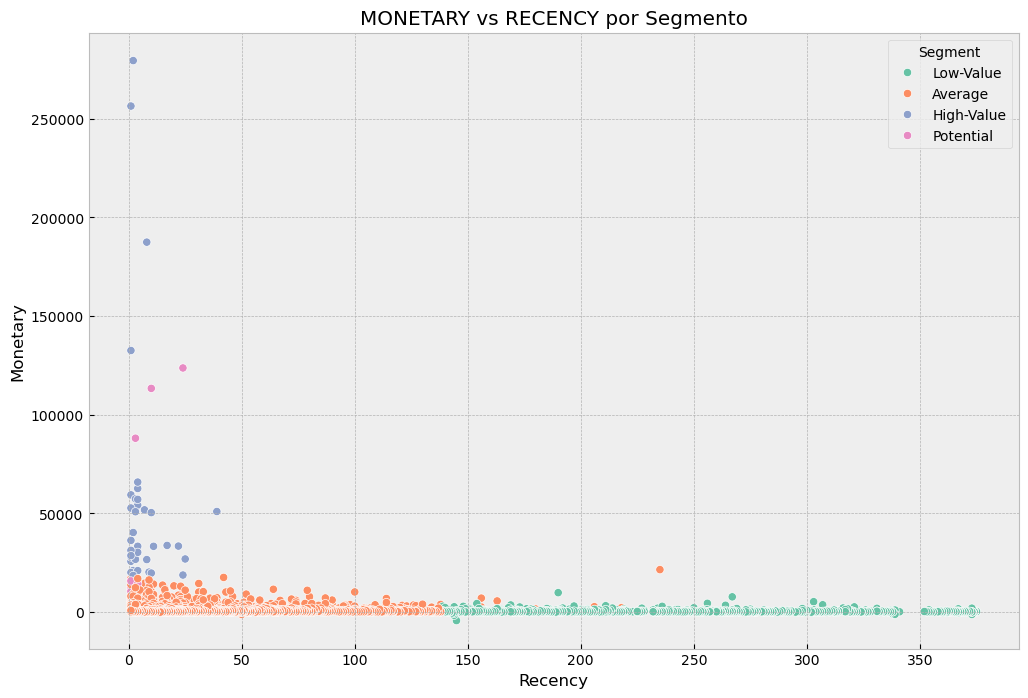

In [113]:
# Define un estilo 'bmh'
plt.style.use("bmh")

# Filtra los valores para RECENCY < 4000
customer_filtrado = customer[customer["RECENCY"] < 4000]

# Crea un grafico de dispersion de 'MONETARY' VS 'RECENCY' por Segmento
import seaborn as sns
plt.figure(figsize=(12,8))
sns.scatterplot(data= customer_filtrado, x = "RECENCY", y = "MONETARY", hue="SEGMENT", palette="Set2")
plt.title("MONETARY vs RECENCY por Segmento")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.legend(title="Segment")
plt.show()





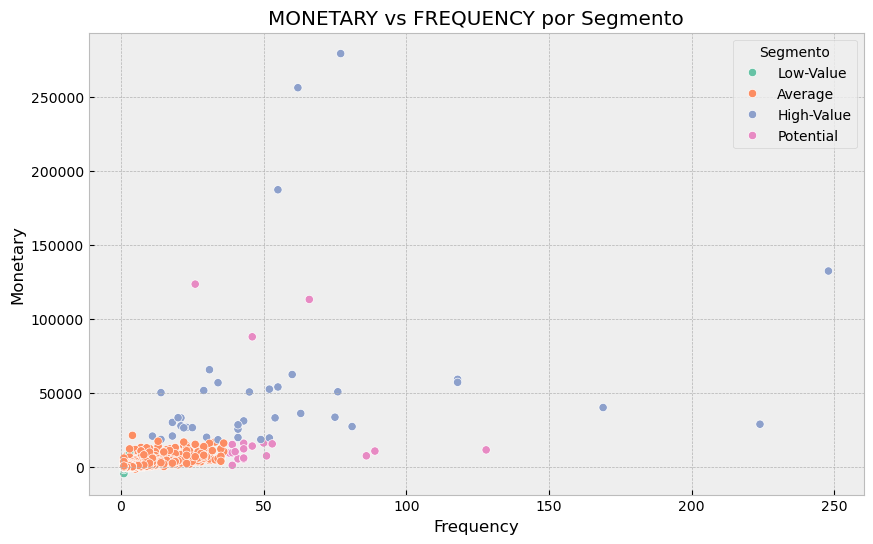

In [121]:
# Crea un grafico de dispersion de 'MONETARY' vs 'FREQUENCY' vs  por Segmento
plt.style.use("bmh")  # Estilo limpio y profesional

plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer, x="FREQUENCY", y="MONETARY", hue="SEGMENT", palette="Set2")
plt.title("MONETARY vs FREQUENCY por Segmento")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.legend(title="Segmento")
plt.show()






### Métrica	      |   Cluster 0 representa...
### Recency	      |   Clientes más recientes
### Frequency     |   Clientes más frecuentes
### Monetary	  |   Clientes más valiosos

# Conclusión personal de INSIGHTS
 # * Insight 1: Pequeño grupo, gran impacto
Aunque el segmento High-Value representa una minoría de clientes, concentra una proporción significativa del gasto total. Esto indica que estos clientes son críticos para el negocio y deben ser priorizados en estrategias de retención y fidelización.

- Acción sugerida: Diseñar campañas exclusivas para este grupo, como recompensas, acceso anticipado o atención personalizada.

 # * Insight 2: Muchos clientes, poco valor
El segmento Low-Value es el más numeroso, pero su contribución al ingreso es mínima. Esto sugiere que hay una gran base de clientes inactivos o poco comprometidos, que podrían estar en riesgo de abandono o simplemente no ser rentables.

- Acción sugerida: Evaluar si vale la pena reactivarlos con ofertas específicas o enfocar recursos en segmentos con mayor potencial.

# *   Insight 3: Clientes potenciales listos para crecer
El segmento Potential muestra buen gasto pero frecuencia moderada, lo que indica que podrían convertirse en High-Value si se activan correctamente. Son clientes con interés y capacidad, pero aún no están plenamente fidelizados.

- Acción sugerida: Activar campañas de engagement, como recordatorios, recomendaciones personalizadas o beneficios por recurrencia.